In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# 1.Introduction

**1.Importing Modules using sklearn**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,PowerTransformer,StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.linear_model import LogisticRegression
from sklearn.impute import IterativeImputer,SimpleImputer,KNNImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest,mutual_info_classif,RFECV
from sklearn.model_selection import RepeatedStratifiedKFold,cross_val_score 



----------------------------------------------------------------------------------------------------------------------------------------------
**2.Dividing the dataset into train and validation**

In [3]:
train=pd.read_csv('/kaggle/input/titanic/train.csv',index_col='PassengerId')
test=pd.read_csv('/kaggle/input/titanic/test.csv')


x=train.drop('Survived',axis=1)
y=train['Survived']

submit=pd.DataFrame(test['PassengerId'])
test=test.set_index('PassengerId')

**3.Basic data description**

In [4]:
print('Shape of train dataset-',train.shape)
print('Shape of valid dataset-',test.shape)

print('------------------------------------------------------------------------------>')

print(train.info())

print('------------------------------------------------------------------------------>')

print('Description of dataset->')
train.describe()

Shape of train dataset- (891, 11)
Shape of valid dataset- (418, 10)
------------------------------------------------------------------------------>
<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB
None
------------------------------------------------------------------------------>
Description of dataset->


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 2.Data Visualization

Just by observing the graph, it can be approximated that the survival rate of men is around 20% and that of women is around 75%.
Therefore, whether a passenger is a male or a female plays an important role in determining if one is going to survive.


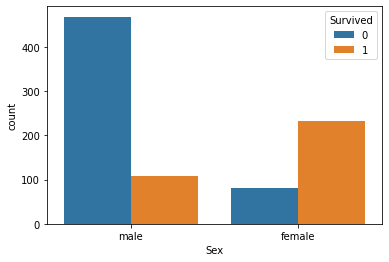

In [5]:
sns.countplot(x='Sex',data=train,hue='Survived')

print('Just by observing the graph, it can be approximated that the survival rate of men is around 20% and that of women is around 75%.\nTherefore, whether a passenger is a male or a female plays an important role in determining if one is going to survive.')


It helps in determining if higher-class passengers had more survival rate than the lower class ones or vice versa. 
Class 1 passengers have a higher survival chance compared to classes 2 and 3. 
It implies that Pclass contributes a lot to a passenger’s survival rate.



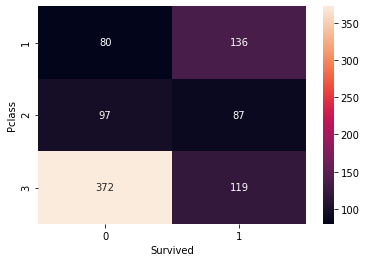

In [6]:
group=train.groupby(['Pclass','Survived'])
pclass_survived = group.size().unstack()
sns.heatmap(pclass_survived,annot=True,fmt='d')

print('\nIt helps in determining if higher-class passengers had more survival rate than the lower class ones or vice versa. \nClass 1 passengers have a higher survival chance compared to classes 2 and 3. \nIt implies that Pclass contributes a lot to a passenger’s survival rate.\n')



This graph gives a summary of the age range of men, women and children who were saved.
The survival rate is –

-> Good for children
-> High for women in the age range 20-50.
-> Less for men as the age increases.


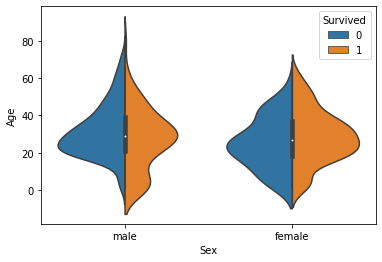

In [7]:
sns.violinplot(y=train['Age'],x=train['Sex'],hue=train['Survived'],split=True)

print('\nThis graph gives a summary of the age range of men, women and children who were saved.\nThe survival rate is –\n')
print('-> Good for children\n-> High for women in the age range 20-50.\n-> Less for men as the age increases.')


/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)
/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3714: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)



->Chance of survival is more with family member of less than 4
->And if a person is alone it has more chance to survive


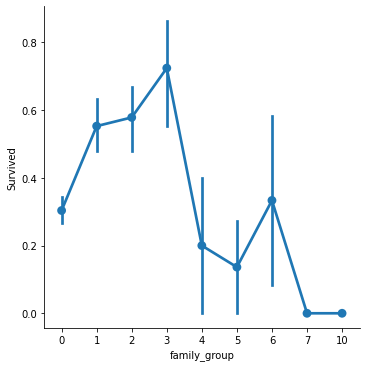

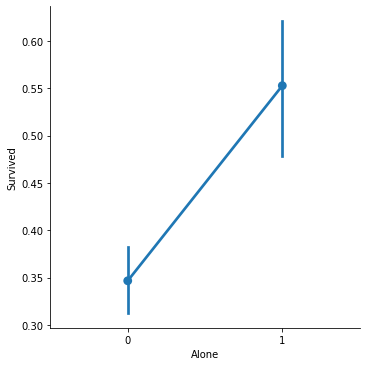

In [8]:
train['family_group']=train['SibSp']+train['Parch']
test['family_group']=test['SibSp']+test['Parch']

train['Alone']=0
train.loc[train['family_group']==1,'Alone']=1
test['Alone']=0
test.loc[test['family_group']==1,'Alone']=1

sns.factorplot(x='family_group',y='Survived',data=train)
sns.factorplot(x='Alone',y='Survived',data=train)


print('\n->Chance of survival is more with family member of less than 4\n->And if a person is alone it has more chance to survive')

People have higher chance of survival if fare is high



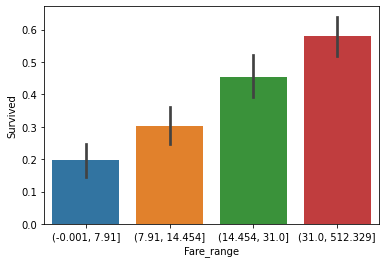

In [9]:
train['Fare_range']=pd.qcut(train['Fare'],4)
sns.barplot(x=train['Fare_range'],y=train['Survived'])
print('People have higher chance of survival if fare is high\n')

# 3.Data Cleaning and Feature extraction

In [10]:
train.drop(['Fare_range','Alone','family_group'],axis=1,inplace=True)

In [11]:
a=[]
for i in range(len(train['Name'])):
    a.append(train['Name'].iloc[i].split(',')[1].split('.')[0])
train['title']=a

In [12]:
train['title']=train['title'].replace([' Dr',' Rev',' Col',' Mlle',' Major',' Jonkheer',' Ms',' Capt',' Mme',' Lady',' Don',' the Countess',' Sir'],'Rare')
train['title']=train['title'].replace({' Mr':1,' Mrs':2,' Miss':3,'Rare':4,' Master':5})

In [13]:
for i in range(len(train['Age'])):
    if(pd.isnull(train['Age'].iloc[i])):
        if(train['title'].iloc[i]==5):
            train['Age'].iloc[i]=5
        elif(train['title'].iloc[i]==4):
            train['Age'].iloc[i]=44
        elif(train['title'].iloc[i]==3):
            train['Age'].iloc[i]=21
        elif(train['title'].iloc[i]==2):
            train['Age'].iloc[i]=35
        else:
            train['Age'].iloc[i]=30
            

/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


In [14]:
for i in range(len(train['Fare'])):
    if(pd.isnull(train['Cabin'].iloc[i])):
        train['Cabin'].iloc[i]=0
    else:
        train['Cabin'].iloc[i]=train['Cabin'].iloc[i][0]
train['Cabin']=train['Cabin'].replace({0:np.nan})

In [15]:
for i in range(len(train)):
    if(pd.isnull(train['Cabin'].iloc[i])):
        if((train['Pclass'].iloc[i]==1) and (train['Embarked'].iloc[i]=='C') and (train['Age'].iloc[i]>30 and train['Age'].iloc[i]<59)):
            train['Cabin'].iloc[i]='A'
        elif((train['Pclass'].iloc[i]==3) and (train['Embarked'].iloc[i]=='S') and (train['Age'].iloc[i]>1 and train['Age'].iloc[i]<45)):
            train['Cabin'].iloc[i]='G'
        elif((train['Pclass'].iloc[i]==1) and (train['Embarked'].iloc[i]=='S') and (train['Age'].iloc[i]<59)):
            train['Cabin'].iloc[i]='T'
        elif((train['Pclass'].iloc[i]==1) and (train['Embarked'].iloc[i]=='A') and (train['Fare'].iloc[i]>26 and train['Age'].iloc[i]<40)):
            train['Cabin'].iloc[i]='A'
        elif((train['Pclass'].iloc[i]==1) and (train['Embarked'].iloc[i]=='S') and (train['Fare'].iloc[i]>42 and train['Age'].iloc[i]<170)):
            train['Cabin'].iloc[i]='T'
        elif((train['Pclass'].iloc[i]==1) and (train['Embarked'].iloc[i]=='C') and (train['Fare'].iloc[i]>40 and train['Age'].iloc[i]<47)):
            train['Cabin'].iloc[i]='A'
        elif((train['Pclass'].iloc[i]==1) and (train['Embarked'].iloc[i]=='A') and (train['Fare'].iloc[i]>26 and train['Age'].iloc[i]<40)):
            train['Cabin'].iloc[i]='A'

In [16]:
train=train.drop(['Ticket','Name'],axis=1)

In [17]:
train['Sex']=train['Sex'].replace({'male':0,'female':1})
train['Cabin']=train['Cabin'].replace({'G':1,'C':2,'B':3,'E':4,'A':5,'T':5,'F':5,'D':5})
train=pd.get_dummies(train,columns=['Embarked'],drop_first=True)

train['Fare']=np.sqrt(train['Fare'])

# Data Modelling

In [18]:
x=train.drop('Survived',axis=1)
y=train['Survived']

In [19]:
for i in range(1,2):
    pipeline=Pipeline(steps=[('impute',KNNImputer(n_neighbors=6)),('encode',StandardScaler()),('model',GradientBoostingClassifier())])
    cv=RepeatedStratifiedKFold(n_repeats=10,n_splits=3,random_state=3)
    score=cross_val_score(pipeline,x,y,cv=cv,scoring='accuracy',n_jobs=-1)
    print(np.mean(score),i)

0.8285072951739617 1
